# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:** Baqar Ali
**Student ID:** 023-24-0015
**Section:** B
**GitHub:** https://github.com/baqar360/ML-Lab-Semester-5
**Kaggle:** https://www.kaggle.com/datasets/baqarali1234/telco-customer-churn
**Dataset:**https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [23]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [24]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split

# Load cleaned dataset
df = pd.read_csv("clean_churn.csv")

# Drop customerID because it is only an identifier
df = df.drop(columns=["customerID"])

# Encode binary categorical columns
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0,
        "Male": 1,
        "Female": 0
    })

# One-hot encode multi-category columns
df = pd.get_dummies(
    df,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True,
    dtype=int
)

# Separate features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
df.head()
df.to_csv("encoded_dataset.csv", index=False)

In [27]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics

# Choose the best depth
best_depth = 2

# Retrain the model
dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Evaluation metrics
print("Final Decision Tree (max_depth=2)")
print("-" * 40)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Final Decision Tree (max_depth=2)
----------------------------------------
Training Accuracy: 0.7912888888888889
Test Accuracy: 0.7846481876332623

Test Precision: 0.6563876651982379
Test Recall: 0.3983957219251337
Test F1 Score: 0.49584026622296173

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy |78 |
| Precision |66 |
| Recall |40 |
| F1-score | 50|

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [28]:
# Task 3 — Train Random Forest and predict on test set

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_test_pred = rf_model.predict(X_test)


**Answer 4:**
_(your answer here)_

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

In [29]:
# Task 5 — Random Forest metrics + confusion matrix

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.7853589196872779
Test Precision: 0.6192052980132451
Test Recall: 0.5
Test F1 Score: 0.5532544378698225

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407


Confusion Matrix:
[[918 115]
 [187 187]]


## **Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7854 |
| Precision | 0.6192 |
| Recall | 0.5000 |
| F1-score | 0.5533 |

**Observation (confusion matrix):**

```text
The Random Forest correctly identified 187 customers who actually churned, while 187 churned customers were missed. It also correctly identified 918 customers who did not churn. Overall, the model has a churn recall of 50%, meaning it detected half of the customers who actually churned.

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

## **Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---:|---:|
| Accuracy | 0.7846 | 0.7854 |
| Precision | 0.6564 | 0.6192 |
| Recall | 0.3984 | 0.5000 |
| F1-score | 0.4958 | 0.5533 |

## **Answer 7:**

The Random Forest performs slightly better overall than the Decision Tree. Both models have almost the same accuracy, but Random Forest has higher recall and F1-score for churn prediction. Its recall improved from approximately 40% to 50%, meaning it can identify more customers who are actually likely to churn. However, the Decision Tree has higher precision, meaning its churn predictions are more precise. Overall, **Random Forest is the better model for this churn prediction task**, especially when detecting churn customers is important.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [30]:
# Task 8 — 5-fold cross-validation for both models

# 5-fold cross-validation for Decision Tree
dt_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

# 5-fold cross-validation for Random Forest
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree F1 Scores:", dt_scores)
print("Decision Tree Mean F1:", dt_scores.mean())
print("Decision Tree Std F1:", dt_scores.std())

print("\nRandom Forest F1 Scores:", rf_scores)
print("Random Forest Mean F1:", rf_scores.mean())
print("Random Forest Std F1:", rf_scores.std())

Decision Tree F1 Scores: [0.52805281 0.52086811 0.45438898 0.49319728 0.50847458]
Decision Tree Mean F1: 0.5009963516990565
Decision Tree Std F1: 0.02613784479951077

Random Forest F1 Scores: [0.56621005 0.55436447 0.52225519 0.54317111 0.56183206]
Random Forest Mean F1: 0.5495665771756093
Random Forest Std F1: 0.015730737959533954


## **Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---:|---:|
| Decision Tree | 0.50 | 0.02 |
| Random Forest | 0.55 | 0.01 |

**Answer 9:**

The cross-validation results support the single train/test split results. Random Forest performed better than the Decision Tree, with a higher mean F1-score of 0.55 compared to 0.50. It also had a lower standard deviation, meaning its performance was more consistent across different folds. Therefore, I am more confident that Random Forest is the better model for this churn prediction task.

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [31]:
# Task 10 — Define a small parameter grid and run GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best cross-validation F1 score
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.5774290942057757


**Answer 11 (best hyperparameters & CV score):**
_(your answer here)_

In [32]:
# Task 12 — evaluate the tuned model on the test set
best_model = grid_search.best_estimator_

y_test_pred_tuned = best_model.predict(X_test)

print("Tuned Random Forest Test Accuracy:",
      accuracy_score(y_test, y_test_pred_tuned))

print("Tuned Random Forest Test Precision:",
      precision_score(y_test, y_test_pred_tuned))

print("Tuned Random Forest Test Recall:",
      recall_score(y_test, y_test_pred_tuned))

print("Tuned Random Forest Test F1 Score:",
      f1_score(y_test, y_test_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_tuned))

Tuned Random Forest Test Accuracy: 0.7882018479033405
Tuned Random Forest Test Precision: 0.6292517006802721
Tuned Random Forest Test Recall: 0.4946524064171123
Tuned Random Forest Test F1 Score: 0.5538922155688623

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## **Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---:|
| Accuracy | 0.7882 |
| Precision | 0.6293 |
| Recall | 0.4947 |
| F1-score | 0.5539 |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

## **Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---:|---:|---:|
| Accuracy | 0.7846 | 0.7854 | 0.7882 |
| Precision | 0.6564 | 0.6192 | 0.6293 |
| Recall | 0.3984 | 0.5000 | 0.4947 |
| F1-score | 0.4958 | 0.5533 | 0.5539 |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

                                  Feature  Importance
4                                  tenure    0.199670
8                            TotalCharges    0.159389
7                          MonthlyCharges    0.112927
11            InternetService_Fiber optic    0.070669
28         PaymentMethod_Electronic check    0.058682
26                      Contract_Two year    0.056456
14                     OnlineSecurity_Yes    0.035472
25                      Contract_One year    0.031212
20                        TechSupport_Yes    0.029338
6                        PaperlessBilling    0.021468
16                       OnlineBackup_Yes    0.016163
3                              Dependents    0.015151
13     OnlineSecurity_No internet service    0.014474
2                                 Partner    0.013892
10                      MultipleLines_Yes    0.013575
0                                  gender    0.013541
1                           SeniorCitizen    0.013341
23    StreamingMovies_No int

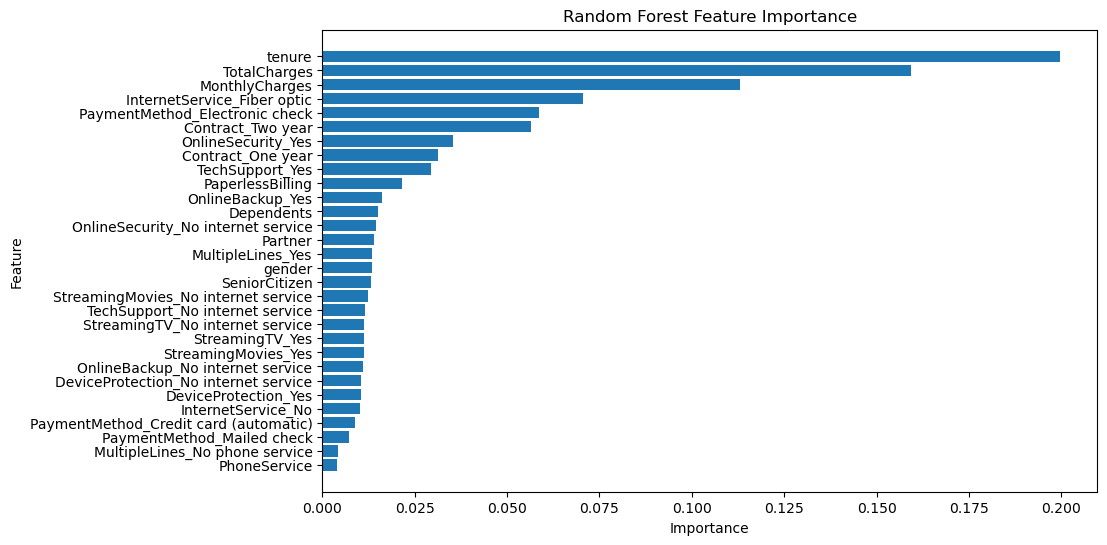

In [34]:
# Task 14 — extract and visualize feature importances
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importances
print(feature_importance)

# Visualize feature importances
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

**Answer 14:**
_(your answer here)_

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
_(your answer here)_

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [ ]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)


---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
For this task, the tuned Random Forest was selected as the final model, since it had the highest F1-score (0.5539) and accuracy (0.7882) among the three models tested. Compared to the Lab 3 Decision Tree baseline, the Random Forest models improved recall substantially (0.40 → 0.49–0.50), meaning they catch far more actual churners, at a small cost to precision (0.66 → 0.62–0.63). Hyperparameter tuning gave only a marginal improvement over the default Random Forest (F1 of 0.5539 vs 0.5533), suggesting the model was already close to its ceiling given the current features. The main limitation is that recall is still under 50%, so roughly half of customers who churn are still missed, and overall performance may be limited more by feature quality than by model choice or tuning at this point.

**Answer 18 — Next steps:**
With more time, I would address the class imbalance directly (e.g. class_weight='balanced' or SMOTE) since churners are a minority class and this is likely holding recall back. I would also try gradient-boosted models like XGBoost or LightGBM, which often outperform Random Forest on tabular data like this. Expanding the hyperparameter search space (e.g. adding max_features, using RandomizedSearchCV over a wider grid) and engineering new features from tenure and billing history could also help push F1 higher.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [ ] Section 1 — Decision Tree Baseline
- [ ] Section 2 — Random Forest
- [ ] Section 3 — Model Evaluation
- [ ] Section 4 — Decision Tree vs Random Forest
- [ ] Section 5 — Cross-Validation
- [ ] Section 6 — Hyperparameter Tuning
- [ ] Section 7 — Final Model Comparison
- [ ] Section 8 — Feature Importance
- [ ] Section 9 — Final Model Selection (justified)
- [ ] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted